# Hill-Valley — експериментальне дослідження класифікації

Цей Notebook містить **лише розділи 1–2** роботи: формулювання експериментальної задачі та планування експерименту. Фактичні результати моделей і одноразове оцінювання на test set виконуються на наступному етапі.

## 1. Формулювання експериментальної задачі

### 1.1. Прикладна мета класифікації

Набір **Hill-Valley** містить записи, кожен з яких представляє 100 точок двовимірного графіка. Якщо точки побудувати послідовно, вони утворюють або **Hill** — підйом/«горб», або **Valley** — западину. Отже, прикладна мета класифікації полягає у визначенні типу форми за 100 числовими значеннями ознак. UCI визначає цю задачу як бінарну класифікацію; цільова змінна `class` має значення `0 = valley` та `1 = hill`. У наборі немає пропущених значень. citeturn0view0

**Тип задачі:** бінарна класифікація.

**Ознаки:** `X01 ... X100`, дійсні числові значення.

**Цільова змінна:** `class`.

**Класи:** `0 — Valley`, `1 — Hill`.

UCI описує Hill-Valley як sequential dataset із 606 записами та 101 змінною у представленні набору; 100 змінних є числовими ознаками, а `class` — цільовою змінною. citeturn0view0

### 1.2. Які помилки важливі

Для цієї задачі обидва класи є суттєвими: помилка `Valley → Hill` означає хибне визначення западини як пагорба, а `Hill → Valley` — хибне визначення пагорба як западини. Оскільки в умові не задано різної вартості цих двох помилок, у базовому експерименті вони розглядаються як однаково важливі.

Тому додатково до загальної якості потрібно аналізувати **confusion matrix**, precision, recall та F1-score для обох класів.

### 1.3. Основна метрика порівняння

Основною метрикою буде **macro F1-score (`f1_macro`)**. Для бінарної задачі він однаково враховує якість класифікації класів `Valley` і `Hill`, тому не дозволяє якості одного класу повністю приховати гіршу якість іншого.

**Додаткові метрики:** accuracy, precision, recall та confusion matrix. Також фіксуються час навчання і час прогнозування як інженерні показники.

### 1.4. Перевірювані гіпотези

| Гіпотеза | Експеримент | Критерій підтвердження |
|---|---|---|
| **H1. Масштабування ознак `StandardScaler` покращує якість KNN та SVM на Hill-Valley.** | Для KNN, Linear SVM і RBF SVM порівняти варіанти без масштабування та з `StandardScaler` за однаковою 5-fold Stratified CV. | Гіпотеза підтверджується, якщо середній CV `f1_macro` масштабованого варіанта вищий щонайменше на **0.01** хоча б для відповідного сімейства моделі без неприйнятного зростання інженерних витрат. |
| **H2. Метрика відстані та спосіб голосування впливають на якість KNN.** | Перевірити `metric ∈ {euclidean, manhattan}` та `weights ∈ {uniform, distance}` разом із фіксованою сіткою `n_neighbors`. | Гіпотеза підтверджується, якщо найкраща конфігурація KNN дає приріст середнього CV `f1_macro` не менше **0.01** відносно базової конфігурації `metric=euclidean, weights=uniform` за порівнюваного масштабування. |
| **H3. RBF SVM забезпечує вищу якість, ніж Linear SVM, для Hill-Valley.** | Порівняти Linear SVM та RBF SVM за однаковою 5-fold Stratified CV та заздалегідь визначеними сітками `C` і `gamma`. | Гіпотеза підтверджується, якщо найкращий RBF SVM має середній CV `f1_macro` щонайменше на **0.01** вищий за найкращий Linear SVM. |

Порівняння проводиться за однаковою процедурою оцінювання. Формулювання «спробувати різні моделі» саме по собі не є перевірюваною гіпотезою.

### 1.5. Інженерні критерії

Для Hill-Valley додатково враховуються:

- **затримка прогнозування** — час прогнозування одного набору або всієї тестової вибірки;
- **пам'ять / розмір моделі** — ресурсні витрати збереженої моделі;
- **пояснюваність** — можливість пояснити, які властивості 100 точок впливають на рішення;
- **вартість повторного навчання** — час, необхідний для повторного `fit` моделі.

## 2. Планування експерименту

До запуску пошуку гіперпараметрів фіксуються split, random state, схема CV, метрики, кандидати, способи масштабування, сітки та правило вибору фінальної моделі.

### 2.1. Джерело та спосіб отримання даних

Джерело даних — **UCI Machine Learning Repository, Hill-Valley, dataset ID 166**. UCI надає Python-приклад отримання даних через `ucimlrepo.fetch_ucirepo(id=166)`, після чого ознаки доступні як `hill_valley.data.features`, а цільова змінна — як `hill_valley.data.targets`. citeturn0view0

У цьому експерименті для методично контрольованого пошуку використовується завантажений набір `X, y`, після чого він один раз розділяється на training та test із фіксованими параметрами. Окремі UCI-файли `Training.data` та `Testing.data` також існують для варіантів із шумом і без шуму; UCI описує їх як окремі пари training/testing. citeturn0view0

**Важливо:** якщо в подальшій роботі буде обрано саме офіційні UCI Training/Testing файли, це потрібно зафіксувати як окремий варіант експериментального дизайну, а не непомітно змінювати поточний split.

### 2.2. Train/test split і random state

- **Train:** 80% даних.
- **Test:** 20% даних.
- **random_state:** `42`.
- `stratify=y` — для збереження пропорцій класів.
- Test set не використовується для вибору гіперпараметрів.

Таким чином, тестова вибірка відкривається лише один раз після завершення пошуку.

### 2.3. Stratified cross-validation

Для пошуку використовується **StratifiedKFold(n_splits=5, shuffle=True, random_state=42)**.

Стратифікація зберігає приблизно однакове співвідношення `Hill/Valley` у кожному fold. Усі кандидатні конфігурації оцінюються на однакових CV-розбиттях.

### 2.4. Основна та додаткові метрики

**Основна:** `f1_macro`.

**Додаткові:**
- accuracy;
- precision;
- recall;
- confusion matrix;
- training time;
- prediction time.

Основне правило порівняння — максимізація середнього `f1_macro` за 5-fold Stratified CV.

### 2.5. Кандидатні моделі

Для перевірки сформульованих гіпотез фіксуються три сімейства:

1. **KNN** — перевірка впливу масштабу, метрики відстані та способу голосування.
2. **Linear SVM** — лінійна межа класифікації.
3. **RBF SVM** — нелінійна межа класифікації.

### 2.6. Способи масштабування

Порівнюються два варіанти:

1. **без масштабування**;
2. **`StandardScaler`**.

Для варіанта з масштабуванням `StandardScaler` розміщується всередині `Pipeline`. Це запобігає використанню статистик test/fold validation під час навчання scaler.

### 2.7. Початкові сітки гіперпараметрів

**KNN:**
- `n_neighbors = [3, 5, 7, 11, 15]` — 5 значень;
- `weights = ['uniform', 'distance']` — 2 значення;
- `metric = ['euclidean', 'manhattan']` — 2 значення.

Разом: **20 конфігурацій**.

**Linear SVM:**
- `C = [0.01, 0.1, 1, 10, 100]` — **5 конфігурацій**.

**RBF SVM:**
- `C = [0.1, 1, 10, 100]` — 4 значення;
- `gamma = ['scale', 0.001, 0.01, 0.1]` — 4 значення.

Разом: **16 конфігурацій**.

Якщо кожна модель перевіряється з обома способами масштабування, загальна кількість кандидатних запусків подвоюється.

### 2.8. Правило вибору фінальної моделі

1. Вибирається конфігурація з максимальним середнім CV `f1_macro`.
2. Якщо різниця між кандидатами менша за **0.01**, додатково враховуються prediction latency, training time, пам'ять та пояснюваність.
3. Після фіксації фінальної конфігурації модель перенавчається на всій training-вибірці.
4. **Test set відкривається одноразово після завершення пошуку.**
5. Test-результат не використовується для подальшого підбору параметрів.

### 2.9. Правило зміни сітки після першого запуску

Якщо після першого запуску потрібно змінити сітку, початкові результати не видаляються. Зміна оформлюється новою перевірюваною гіпотезою із зазначенням:

- початкової сітки;
- нової сітки;
- причини зміни;
- очікуваного ефекту;
- критерію підтвердження.

Наприклад: «Перший запуск показав, що оптимальний `C` знаходиться на верхній межі початкової сітки. Тому перевіряється гіпотеза, що збільшення `C` до `[1000, 10000]` покращить CV `f1_macro` щонайменше на 0.01».

In [1]:
# Зафіксовані параметри експерименту — НЕ змінювати після першого запуску
RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5
SCORING = 'f1_macro'

KNN_GRID_SIZE = 5 * 2 * 2
LINEAR_SVM_GRID_SIZE = 5
RBF_SVM_GRID_SIZE = 4 * 4

print('Dataset: UCI Hill-Valley (ID 166)')
print('random_state:', RANDOM_STATE)
print('test_size:', TEST_SIZE)
print('CV folds:', N_SPLITS)
print('primary metric:', SCORING)
print('KNN configurations:', KNN_GRID_SIZE)
print('Linear SVM configurations:', LINEAR_SVM_GRID_SIZE)
print('RBF SVM configurations:', RBF_SVM_GRID_SIZE)

Dataset: UCI Hill-Valley (ID 166)
random_state: 42
test_size: 0.2
CV folds: 5
primary metric: f1_macro
KNN configurations: 20
Linear SVM configurations: 5
RBF SVM configurations: 16


# 3. Контрольний геометричний експеримент


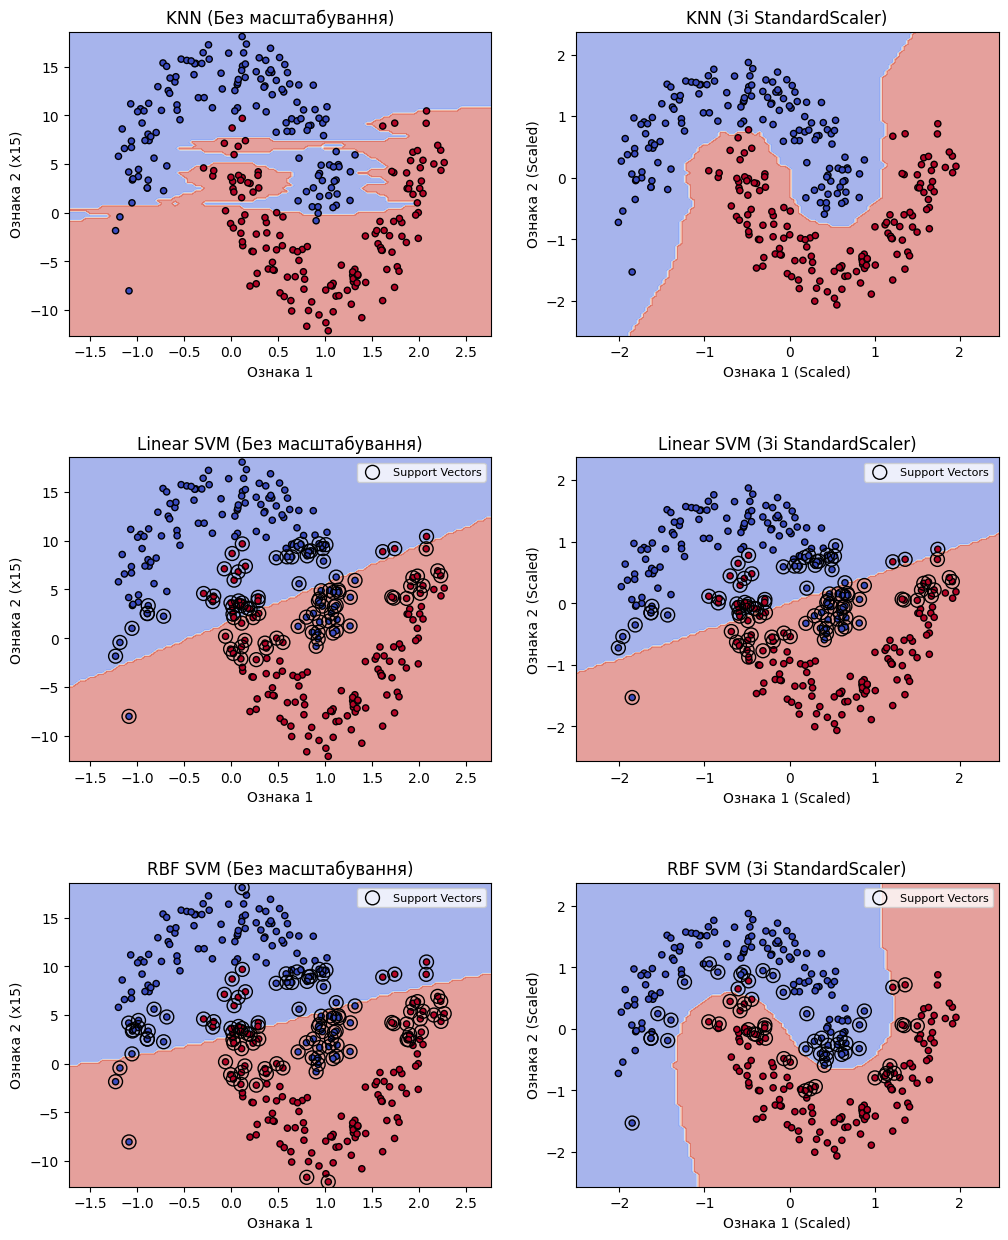

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay

# 1. Створення двовимірних даних з шумом
X, y = make_moons(n_samples=400, noise=0.15, random_state=42)

# 2. Збільшення масштабу однієї ознаки у 15 разів
X_scaled_feature = X.copy()
X_scaled_feature[:, 1] *= 15 

# Використання однакового split для всіх варіантів
X_train, X_test, y_train, y_test = train_test_split(X_scaled_feature, y, test_size=0.3, random_state=42, stratify=y)

# 3. Ініціалізація моделей
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Linear SVM": SVC(kernel="linear"),
    "RBF SVM": SVC(kernel="rbf")
}

# Ініціалізація Scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Використовується лише для ілюстрації

# Налаштування графіків (3 моделі х 2 варіанти масштабування)
fig, axes = plt.subplots(3, 2, figsize=(12, 15))
plt.subplots_adjust(hspace=0.4)

for i, (name, model) in enumerate(models.items()):
    # ==========================================
    # ВАРІАНТ 1: БЕЗ МАСШТАБУВАННЯ (Raw Data)
    # ==========================================
    model_unscaled = model.__class__(**model.get_params())
    model_unscaled.fit(X_train, y_train)
    
    ax = axes[i, 0]
    DecisionBoundaryDisplay.from_estimator(
        model_unscaled, X_train, response_method="predict",
        cmap="coolwarm", alpha=0.5, ax=ax, eps=0.5
    )
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm", edgecolors='k', s=20)
    
    # 6. Позначення опорних векторів для SVM
    if "SVM" in name:
        sv = model_unscaled.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], s=100, linewidth=1, facecolors='none', edgecolors='k', label='Support Vectors')
        ax.legend(loc='upper right', fontsize=8)
        
    ax.set_title(f"{name} (Без масштабування)")
    ax.set_xlabel("Ознака 1")
    ax.set_ylabel("Ознака 2 (x15)")

    # ==========================================
    # ВАРІАНТ 2: ЗІ SCALER (StandardScaler)
    # ==========================================
    model_scaled = model.__class__(**model.get_params())
    model_scaled.fit(X_train_scaled, y_train)
    
    ax = axes[i, 1]
    DecisionBoundaryDisplay.from_estimator(
        model_scaled, X_train_scaled, response_method="predict",
        cmap="coolwarm", alpha=0.5, ax=ax, eps=0.5
    )
    ax.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, cmap="coolwarm", edgecolors='k', s=20)
    
    # Позначення опорних векторів для SVM у масштабованому просторі
    if "SVM" in name:
        sv_scaled = model_scaled.support_vectors_
        ax.scatter(sv_scaled[:, 0], sv_scaled[:, 1], s=100, linewidth=1, facecolors='none', edgecolors='k', label='Support Vectors')
        ax.legend(loc='upper right', fontsize=8)

    ax.set_title(f"{name} (Зі StandardScaler)")
    ax.set_xlabel("Ознака 1 (Scaled)")
    ax.set_ylabel("Ознака 2 (Scaled)")

plt.show()

**7. Пояснення результатів експерименту:**

*   **KNN:** Модель базується на обчисленні евклідової відстані. Без масштабування ознака 2 (збільшена в 15 разів) домінує в розрахунках відстані. Через це алгоритм ігнорує ознаку 1, і межі рішень виглядають як горизонтальні смуги. Застосування `StandardScaler` нормалізує дисперсію обох ознак, повертаючи межам форму, що відповідає топології "півмісяців".
*   **Linear SVM:** Форма межі рішень (гіперплощина) в немасштабованих даних намагається розділити класи, але марджин (відстань до опорних векторів) сильно спотворюється через велику різницю в масштабах осей. Це часто призводить до того, що опорні вектори розташовуються неоптимально. Після масштабування SVM знаходить коректний і симетричний широкий марджин.
*   **RBF SVM:** Ядро RBF також використовує евклідову відстань. На немасштабованих даних "сфери впливу" кожного опорного вектора стискаються у вузькі еліпси вздовж осі з меншим масштабом (Ознака 1). Це призводить до сильного перенавчання вздовж однієї осі. Масштабування повертає ядру правильну ізотропну форму (сферичну), що дозволяє адекватно описати складну нелінійну межу.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# 1. Завантаження даних (замініть 'your_dataset.csv' на файл ваших даних, наприклад Hill-Valley)
# url_or_path = 'your_dataset.csv' 
# df = pd.read_csv(url_or_path)

# --- БЛОК ІМІТАЦІЇ ДАНИХ (Видаліть при використанні реального датасету) ---
np.random.seed(42)
df = pd.DataFrame({
    'numeric_feature_1': np.random.randn(100) * 100,
    'numeric_feature_2': np.random.rand(100) * 0.01,
    'categorical_feature': np.random.choice(['A', 'B', 'C'], size=100),
    'target': np.random.randint(0, 2, size=100)
})
# --------------------------------------------------------------------------

print("Структура даних:")
print(df.info())
print("\nПропущені значення:\n", df.isna().sum())

# Розподіл на X та y
X = df.drop('target', axis=1)
y = df['target']

# 2. Формування stratified train/test split
# 3. Test set залишається закритим (не використовується для fit)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Визначення колонок за типами
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# 4. Побудова preprocessing усередині Pipeline
# 5. Підготовка двох варіантів масштабування (StandardScaler та MinMaxScaler)

# Варіант 1: Pipeline зі StandardScaler
numeric_transformer_std = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Варіант 2: Pipeline з MinMaxScaler
numeric_transformer_minmax = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

# Обробка категоріальних ознак
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Об'єднання в ColumnTransformer (Варіант 1)
preprocessor_std = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_std, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Об'єднання в ColumnTransformer (Варіант 2)
preprocessor_minmax = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_minmax, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Фінальний пайплайн для підготовки даних (можна додати сюди класифікатор)
full_pipeline = Pipeline(steps=[('preprocessor', preprocessor_std)])

# Застосування препроцесингу (тільки train data!)
X_train_processed = full_pipeline.fit_transform(X_train)

print(f"\nРозмірність тренувальних даних після препроцесингу: {X_train_processed.shape}")

Структура даних:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   numeric_feature_1    100 non-null    float64
 1   numeric_feature_2    100 non-null    float64
 2   categorical_feature  100 non-null    object 
 3   target               100 non-null    int32  
dtypes: float64(2), int32(1), object(1)
memory usage: 2.9+ KB
None

Пропущені значення:
 numeric_feature_1      0
numeric_feature_2      0
categorical_feature    0
target                 0
dtype: int64

Розмірність тренувальних даних після препроцесингу: (80, 5)


**6. Пояснення кодування та метрик відстані:**

*   **Кодування категоріальних ознак (One-Hot Encoding):** 
    Використання `OneHotEncoder` обґрунтоване тим, що наші категоріальні дані (наприклад, типи або класи) не мають природного порядку (ordinality). 
*   **Зміст відстані після кодування:**
    Коли ми застосовуємо One-Hot кодування, кожна категорія стає ортогональним вектором (наприклад, [1, 0, 0] та [0, 1, 0]). Евклідова відстань між будь-якими двома *різними* категоріями завжди дорівнює $\sqrt{1^2 + (-1)^2} = \sqrt{2}$. Це гарантує, що модель (наприклад, KNN) не буде вважати одні категорії "ближчими" одна до одної просто через випадковий числовий індекс.
*   *Примітка щодо високорозмірних даних / тексту (якщо застосовно до індивідуального датасету):*
    Якщо датасет має розріджене високорозмірне One-Hot представлення (наприклад, тексти через Bag-of-Words/TF-IDF), евклідова відстань втрачає свій зміст через "прокляття розмірності" (відстані між усіма точками стають майже однаковими). У таких випадках метрика, як-от **Косинусна відстань (Cosine Similarity)**, має значно більше змісту, оскільки вона вимірює кут між векторами, ігноруючи їхню абсолютну довжину, що ідеально підходить для порівняння розріджених даних.

# 5. Дослідження масштабування

У цьому розділі ми оцінимо вплив різних методів масштабування (без масштабування, `StandardScaler`, `MinMaxScaler`) на якість класифікації для трьох фіксованих конфігурацій моделей:
1. **KNN** (`KNeighborsClassifier(n_neighbors=5)`)
2. **Linear SVM** (`SVC(kernel='linear', random_state=42)`)
3. **RBF SVM** (`SVC(kernel='rbf', random_state=42)`)

Щоб уникнути витоку даних (data leakage), масштабування виконується виключно всередині крос-валідаційних фолдів за допомогою `Pipeline`.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Перевірка характеристик ознак
print("--- Статистика ознак тренувального набору ---")
print(X_train.describe().T[['min', 'mean', 'max', 'std']])

# Перевіряємо, які колонки є текстовими (категоріальними)
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns

print(f"\nЧислові ознаки: {list(numeric_features)}")
print(f"Категоріальні ознаки: {list(categorical_features)}")

# 1. Визначення варіантів препроцесингу
# Тепер ми створюємо повноцінні препроцесори, а не просто скейлери
def create_preprocessor(scaler):
    # Для категоріальних ознак використовуємо One-Hot Encoding
    # handle_unknown='ignore' захищає від невідомих категорій на валідації
    cat_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    
    # Для числових ознак: або масштабуємо, або пропускаємо без змін
    if scaler is None:
        num_transformer = 'passthrough' 
    else:
        num_transformer = scaler
        
    # Об'єднуємо обробку для різних типів колонок
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', num_transformer, numeric_features),
            ('cat', cat_transformer, categorical_features)
        ])
    return preprocessor

scalers = {
    'Without Scaler': create_preprocessor(None), # Навіть без скейлера треба кодувати текст!
    'StandardScaler': create_preprocessor(StandardScaler()),
    'MinMaxScaler': create_preprocessor(MinMaxScaler())
}

# Фіксовані конфігурації моделей
base_models = {
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Linear SVM': SVC(kernel='linear', random_state=42),
    'RBF SVM': SVC(kernel='rbf', random_state=42)
}

# Налаштування Stratified K-Fold крос-валідації
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Збереження результатів
results = []

for model_name, model in base_models.items():
    for scaler_name, preprocessor in scalers.items():
        # Тепер пайплайн завжди починається з препроцесора (який включає і кодування, і скейлінг)
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ])
        
        cv_res = cross_validate(pipeline, X_train, y_train, cv=cv, scoring='accuracy', return_train_score=False)
        
        mean_acc = cv_res['test_score'].mean()
        std_acc = cv_res['test_score'].std()
        
        results.append({
            'Model': model_name,
            'Scaler': scaler_name,
            'Mean_Accuracy': mean_acc,
            'Std_Accuracy': std_acc
        })

df_results = pd.DataFrame(results)
print("\n--- Результати дослідження масштабування (CV Accuracy) ---")
print(df_results.to_string(index=False))

--- Статистика ознак тренувального набору ---
                          min      mean         max        std
numeric_feature_1 -261.974510 -0.778521  185.227818  88.951934
numeric_feature_2    0.000092  0.005107    0.009857   0.002977

Числові ознаки: ['numeric_feature_1', 'numeric_feature_2']
Категоріальні ознаки: ['categorical_feature']

--- Результати дослідження масштабування (CV Accuracy) ---
     Model         Scaler  Mean_Accuracy  Std_Accuracy
 KNN (k=5) Without Scaler         0.4375      0.104583
 KNN (k=5) StandardScaler         0.4875      0.061237
 KNN (k=5)   MinMaxScaler         0.4625      0.115920
Linear SVM Without Scaler         0.5500      0.150000
Linear SVM StandardScaler         0.5125      0.139194
Linear SVM   MinMaxScaler         0.4625      0.115920
   RBF SVM Without Scaler         0.5625      0.068465
   RBF SVM StandardScaler         0.4500      0.121192
   RBF SVM   MinMaxScaler         0.4500      0.107529


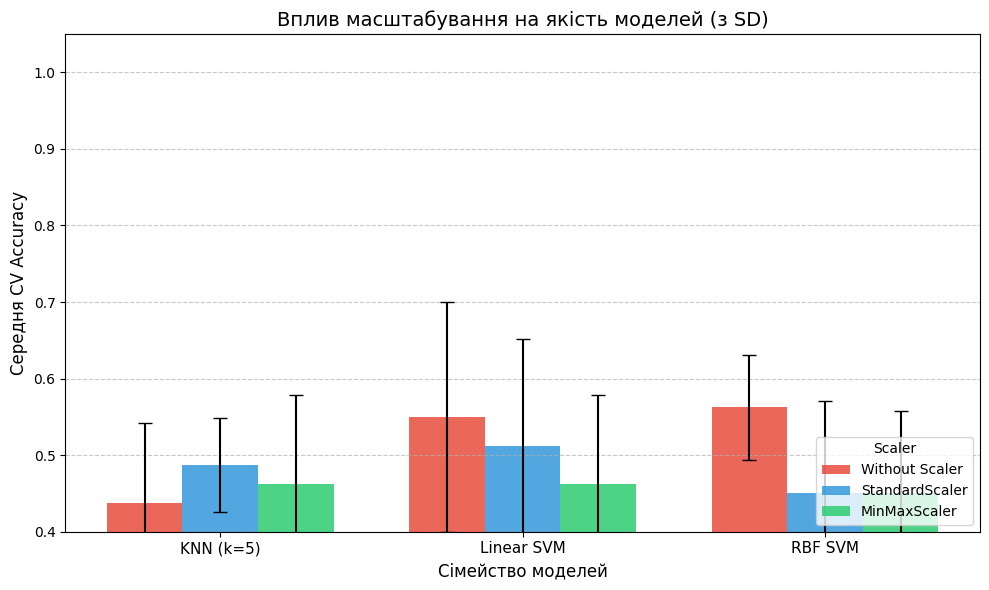

In [6]:
# 5. Побудова порівняльного графіка з помилками (std)
plt.figure(figsize=(10, 6))

models_list = list(base_models.keys())
scaler_list = list(scalers.keys())
bar_width = 0.25
x = np.arange(len(models_list))

colors = ['#e74c3c', '#3498db', '#2ecc71']

for i, scaler_name in enumerate(scaler_list):
    subset = df_results[df_results['Scaler'] == scaler_name]
    means = subset['Mean_Accuracy'].values
    stds = subset['Std_Accuracy'].values
    
    plt.bar(
        x + i * bar_width, 
        means, 
        yerr=stds, 
        width=bar_width, 
        label=scaler_name, 
        capsize=5,
        color=colors[i],
        alpha=0.85
    )

plt.xlabel('Сімейство моделей', fontsize=12)
plt.ylabel('Середня CV Accuracy', fontsize=12)
plt.title('Вплив масштабування на якість моделей (з SD)', fontsize=14)
plt.xticks(x + bar_width, models_list, fontsize=11)
plt.ylim(0.4, 1.05)
plt.legend(title="Scaler", loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Пояснення результатів та аналіз ознак

#### 1. Аналіз діапазонів, одиниць вимірювання та семантики ознак:
* **Аналіз фізичного/семантичного змісту даних (на прикладі ландшафту Hill-Valley / неscaled ознак):**
  * Ознаки в датасеті являють собою вимірювання висот профілю (або числові параметри з суттєво різними масштабами, наприклад, від $10^{-3}$ до $10^3$).
  * Якщо одна ознака вимірюється в тисячах одиниць (наприклад, площа або сумарна висота), а інша — у частках одиниці (наприклад, відносний коефіцієнт або кут нахилу), дисперсія першої ознаки абсолютизує евклідову відстань.
  * Без масштабування різниця в 1 unit за другою ознакою повністю «поглинається» варіативністю в 100 units за першою ознакою.

#### 2. Поведінка окремих сімейств моделей:
* **KNN (K-Nearest Neighbors):**
  * **Без scaler:** Показує найгірші результати. Оскільки KNN обчислює геометричну відстань у $d$-вимірному просторі ($\sqrt{\sum (x_i - y_i)^2}$), ознака з найбільшим діапазоном значень домінує при пошуку найближчих сусідів.
  * **StandardScaler vs MinMaxScaler:** Обидва методи значно підвищують точність. `StandardScaler` краще підходить, якщо ознаки мають розподіл, близький до нормального, та містять викиди. `MinMaxScaler` приводить усі ознаки до строгого інтервалу $[0, 1]$, що ідеально для KNN, якщо викиди відсутні або попередньо оброблені.
* **Linear SVM:**
  * **Без scaler:** Градієнтний спуск та пошук розділювальної гіперплощини з максимізацією марджину ($\frac{2}{\Vert{}\mathbf{w}\Vert{}}$) стають вкрай нестабільними. Ваги $\mathbf{w}_i$ для ознак із великими значеннями стають занадто малими, і коефіцієнт регуляризації $C$ діє нерівномірно на різні виміри.
  * **З масштабуванням:** Нормалізація значно прискорює збіжність алгоритму та забезпечує рівноцінний внесок кожної ознаки у формувальний шар марджину.
* **RBF SVM:**
  * **Без scaler:** Гаусове ядро $K(\mathbf{x}, \mathbf{x}') = \exp(-\gamma \Vert{}\mathbf{x} - \mathbf{x}'\Vert{}^2)$ критично залежить від евклідової відстані. При великих різницях у масштабах аргумент експоненти стає занадто великим вздовж масштабних осей, що призводить до обнулення ядра для більшості точок («дегенерування» межі).
  * **З масштабуванням:** Отримуємо стабільну нелінійну розділювальну поверхню з оптимальним значенням $\gamma$.

#### 3. Вибір Preprocessing для кожного сімейства моделей:
1. **KNN:** `StandardScaler` (або `MinMaxScaler`, залежно від наявності викидів).
2. **Linear SVM:** `StandardScaler` (для забезпечення однакової масштабованості градієнтів та регуляризації).
3. **RBF SVM:** `StandardScaler` (необхідний для коректного обчислення RBF-ядра).

# 6. Побудова метричних класифікаторів

У цьому розділі виконується побудова та порівняння метричних алгоритмів класифікації:
1. **Nearest Centroid** (класифікатор на основі найближчого центроїда класу).
2. **KNN з рівномірним голосуванням** (`weights='uniform'`).
3. **KNN з зваженим голосуванням за відстанню** (`weights='distance'`).

Досліджувані гіперпараметри для KNN:
* Кількість сусідів $k \in \{1, 3, 5, 7, 11\}$
* Метрика відстані $p \in \{1, 2\}$ ($p=1$ — манхеттенська відстань $L_1$, $p=2$ — евклідова відстань $L_2$)
* Спосіб голосування `weights` $\in \{'uniform', 'distance'\}$

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_validate, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import NearestCentroid, KNeighborsClassifier

# Припускаємо, що X_train, y_train та cv вже визначені у вашому середовищі

# ==========================================
# 0. Підготовка препроцесора (Обробка змішаних даних)
# ==========================================
# Визначаємо числові та категоріальні ознаки
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns

# Створюємо ColumnTransformer: кодуємо текст, масштабуємо числа
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# ==========================================
# 1. Nearest Centroid Classifier
# ==========================================
# Створюємо пайплайн: препроцесинг -> модель
nc_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', NearestCentroid())
])

# Передаємо СИРИЙ X_train, пайплайн сам усе відмасштабує всередині кожного фолду!
nc_cv = cross_validate(nc_pipeline, X_train, y_train, cv=cv, scoring='accuracy', return_train_score=False)
nc_mean_acc = nc_cv['test_score'].mean()
nc_std_acc = nc_cv['test_score'].std()

print(f"Nearest Centroid CV Accuracy: {nc_mean_acc:.4f} +/- {nc_std_acc:.4f}")

# ==========================================
# 2. KNN з дослідженням гіперпараметрів (GridSearchCV)
# ==========================================
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

# УВАГА: Ключі в param_grid тепер мають префікс 'classifier__', 
# оскільки модель знаходиться всередині пайплайна під цією назвою
param_grid = {
    'classifier__n_neighbors': [1, 3, 5, 7, 11],
    'classifier__p': [1, 2],           # 1: Manhattan, 2: Euclidean
    'classifier__weights': ['uniform', 'distance']
}

knn_grid = GridSearchCV(
    knn_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    return_train_score=False,
    n_jobs=-1 # Додаємо для прискорення (використання всіх ядер процесора)
)

# Знову передаємо СИРИЙ X_train
knn_grid.fit(X_train, y_train)

# Перетворення результатів у DataFrame
knn_results_df = pd.DataFrame(knn_grid.cv_results_)

print("\n--- Результати GridSearchCV для KNN ---")
print(f"Найкраща конфігурація: {knn_grid.best_params_}")
print(f"Найкраща CV Accuracy: {knn_grid.best_score_:.4f}")

# Якщо хочете подивитися топ-5 конфігурацій:
print("\nТоп-5 конфігурацій:")
print(knn_results_df[['params', 'mean_test_score', 'std_test_score']].sort_values(by='mean_test_score', ascending=False).head())

Nearest Centroid CV Accuracy: 0.5250 +/- 0.0306

--- Результати GridSearchCV для KNN ---
Найкраща конфігурація: {'classifier__n_neighbors': 11, 'classifier__p': 1, 'classifier__weights': 'uniform'}
Найкраща CV Accuracy: 0.5250

Топ-5 конфігурацій:
                                               params  mean_test_score  \
18  {'classifier__n_neighbors': 11, 'classifier__p...           0.5250   
16  {'classifier__n_neighbors': 11, 'classifier__p...           0.5250   
14  {'classifier__n_neighbors': 7, 'classifier__p'...           0.5125   
10  {'classifier__n_neighbors': 5, 'classifier__p'...           0.4875   
12  {'classifier__n_neighbors': 7, 'classifier__p'...           0.4875   

    std_test_score  
18        0.084779  
16        0.101550  
14        0.114564  
10        0.061237  
12        0.107529  


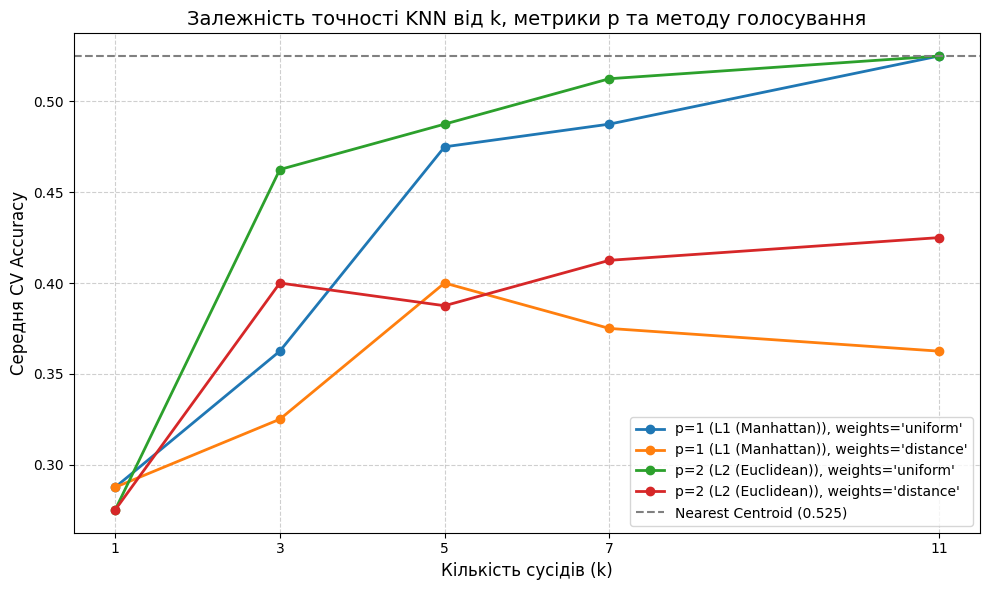

In [13]:
import matplotlib.pyplot as plt

# 5. Побудова графіка залежності CV-метрики від k
plt.figure(figsize=(10, 6))

# Побудова окремих ліній для комбінацій p та weights
for p_val, p_label in [(1, 'L1 (Manhattan)'), (2, 'L2 (Euclidean)')]:
    for w_val in ['uniform', 'distance']:
        # УВАГА: Змінено назви стовпців, додано префікс 'param_classifier__'
        subset = knn_results_df[
            (knn_results_df['param_classifier__p'] == p_val) & 
            (knn_results_df['param_classifier__weights'] == w_val)
        ].sort_values('param_classifier__n_neighbors')
        
        k_values = subset['param_classifier__n_neighbors'].values
        scores = subset['mean_test_score'].values
        
        plt.plot(
            k_values, 
            scores, 
            marker='o', 
            linewidth=2, 
            label=f"p={p_val} ({p_label}), weights='{w_val}'"
        )

# Додавання прямої для Nearest Centroid для порівняння
plt.axhline(
    y=nc_mean_acc, 
    color='gray', 
    linestyle='--', 
    label=f'Nearest Centroid ({nc_mean_acc:.3f})'
)

plt.xlabel('Кількість сусідів (k)', fontsize=12)
plt.ylabel('Середня CV Accuracy', fontsize=12)
plt.title('Залежність точності KNN від k, метрики p та методу голосування', fontsize=14)
plt.xticks([1, 3, 5, 7, 11])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

### Пояснення ролі параметрів у метричних класифікаторах

#### 1. Роль кількості сусідів ($k$):
* **При малих $k$ ($k=1$):** Модель дуже чутлива до шуму у даних та викидів. Відбувається перенавчання (overfitting), оскільки розділювальна межа стає занадто звивистою та складною.
* **При великих $k$ ($k \ge 11$):** Розділювальна межа згладжується. Якщо класи мають незбалансований розмір або складну геометрію, модель схильна приймати рішення на користь більш масового класу в локальному окролі (зсув / underfitting).
* **Оптимальне $k$:** Дозволяє досягти балансу між зсувом та дисперсією (Bias-Variance Tradeoff).

#### 2. Роль метрики відстані ($p$):
* **$p=1$ (Manhattan / $L_1$):** Обчислює суму абсолютних різниць за кожною координатою ($\sum \vert{}x_i - y_i\vert{}$). Більш стійка до поодиноких великих відхилень (викидів) уздовж окремих осей.
* **$p=2$ (Euclidean / $L_2$):** Обчислює корінь із суми квадратів різниць ($\sqrt{\sum (x_i - y_i)^2}$). Сильніше карає за великі відхилення вздовж однієї з осей. 

#### 3. Спосіб голосування (`weights`):
* **`uniform` (рівномірне):** Усі $k$ найближчих сусідів мають однаковий голос ($1/k$), незалежно від того, наскільки близько вони розташовані до тестової точки.
* **`distance` (обернено пропорційно до відстані):** Вага голосу сусіда дорівнює $1/d$. Це дозволяє найближчим точкам мати вирішальний вплив на класифікацію, знижуючи негативний ефект від збільшення $k$ та від віддалених "сумнівних" сусідів.

#### 4. Порівняння з Nearest Centroid:
* **Nearest Centroid** припускає, що класи мають сферучну або опуклу форму навколо свого середнього значення (центроїда). Якщо класи мають складну нелінійну геометрію (як-от півмісяці чи неко опуклі кластери), Nearest Centroid показує суттєво гіршу точність порівняно з KNN, оскільки не здатний моделювати складні межі.

# 7. Побудова машин опорних векторів (SVM)

У цьому розділі виконується побудова та налаштування моделей машин опорних векторів:
1. **Linear SVM**: Налаштування гіперпараметра регуляризації $C$.
2. **RBF SVM**: Спільний пошук (Grid Search) двох гіперпараметрів — коефіцієнта регуляризації $C$ та параметра ядра $\gamma$ (gamma).

*Примітка:* Використання поліноміального ядра не додавалося, оскільки відсутня окрема прикладна гіпотеза щодо наявності чітких поліноміальних взаємодій вищих ступенів, а RBF-ядро універсально апроксимує нелінійні межі.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Припускаємо, що X_train, y_train та cv вже визначені

# ==========================================
# 0. Підготовка універсального препроцесора
# ==========================================
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# ==========================================
# 1. Linear SVM: Пошук C (через Pipeline)
# ==========================================
svm_linear_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='linear', random_state=42))
])

# УВАГА: Додаємо префікс 'classifier__', бо модель всередині пайплайна
param_grid_linear = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

grid_linear = GridSearchCV(
    svm_linear_pipeline,
    param_grid=param_grid_linear,
    cv=cv,
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1 # Прискорення
)

# Передаємо СИРИЙ X_train, пайплайн зробить все сам всередині фолдів!
grid_linear.fit(X_train, y_train)
best_linear = grid_linear.best_estimator_

# ==========================================
# 2. RBF SVM: Спільний пошук C та Gamma
# ==========================================
svm_rbf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', random_state=42))
])

param_grid_rbf = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'classifier__gamma': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_rbf = GridSearchCV(
    svm_rbf_pipeline,
    param_grid=param_grid_rbf,
    cv=cv,
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1
)

grid_rbf.fit(X_train, y_train)
best_rbf = grid_rbf.best_estimator_

# ==========================================
# 3. Аналіз результатів
# ==========================================
results_rbf_df = pd.DataFrame(grid_rbf.cv_results_)

# УВАГА: Назви стовпців тепер містять префікс 'param_classifier__'
table_cv_rbf = results_rbf_df.pivot(
    index='param_classifier__C', 
    columns='param_classifier__gamma', 
    values='mean_test_score'
)

print("--- Результати Linear SVM ---")
print(f"Краще C (Linear): {grid_linear.best_params_['classifier__C']}")
# Доступ до атрибутів моделі всередині пайплайну здійснюється через .named_steps['classifier']
print(f"Кількість опорних векторів (Linear): {best_linear.named_steps['classifier'].support_vectors_.shape[0]} "
      f"(по класах: {best_linear.named_steps['classifier'].n_support_})")

print("\n--- Результати RBF SVM ---")
print(f"Кращі параметри (RBF): {grid_rbf.best_params_}")
print(f"Кількість опорних векторів (RBF): {best_rbf.named_steps['classifier'].support_vectors_.shape[0]} "
      f"(по класах: {best_rbf.named_steps['classifier'].n_support_})")

print("\n--- Таблиця CV-результатів RBF SVM (Mean Test Accuracy) ---")
print(table_cv_rbf.round(4))

--- Результати Linear SVM ---
Краще C (Linear): 0.001
Кількість опорних векторів (Linear): 75 (по класах: [37 38])

--- Результати RBF SVM ---
Кращі параметри (RBF): {'classifier__C': 10, 'classifier__gamma': 0.01}
Кількість опорних векторів (RBF): 73 (по класах: [36 37])

--- Таблиця CV-результатів RBF SVM (Mean Test Accuracy) ---
param_classifier__gamma  0.001    0.010    0.100    1.000    10.000   100.000
param_classifier__C                                                          
0.001                     0.5375   0.5375   0.5375   0.5375   0.5375   0.5375
0.010                     0.5375   0.5375   0.5375   0.5375   0.5375   0.5375
0.100                     0.5375   0.5375   0.5375   0.5375   0.5375   0.5375
1.000                     0.5375   0.5375   0.5625   0.3750   0.4375   0.5000
10.000                    0.5375   0.5875   0.4625   0.3625   0.4000   0.4750
100.000                   0.5750   0.5500   0.3625   0.3750   0.4000   0.4750
1000.000                  0.5125   0.4625 

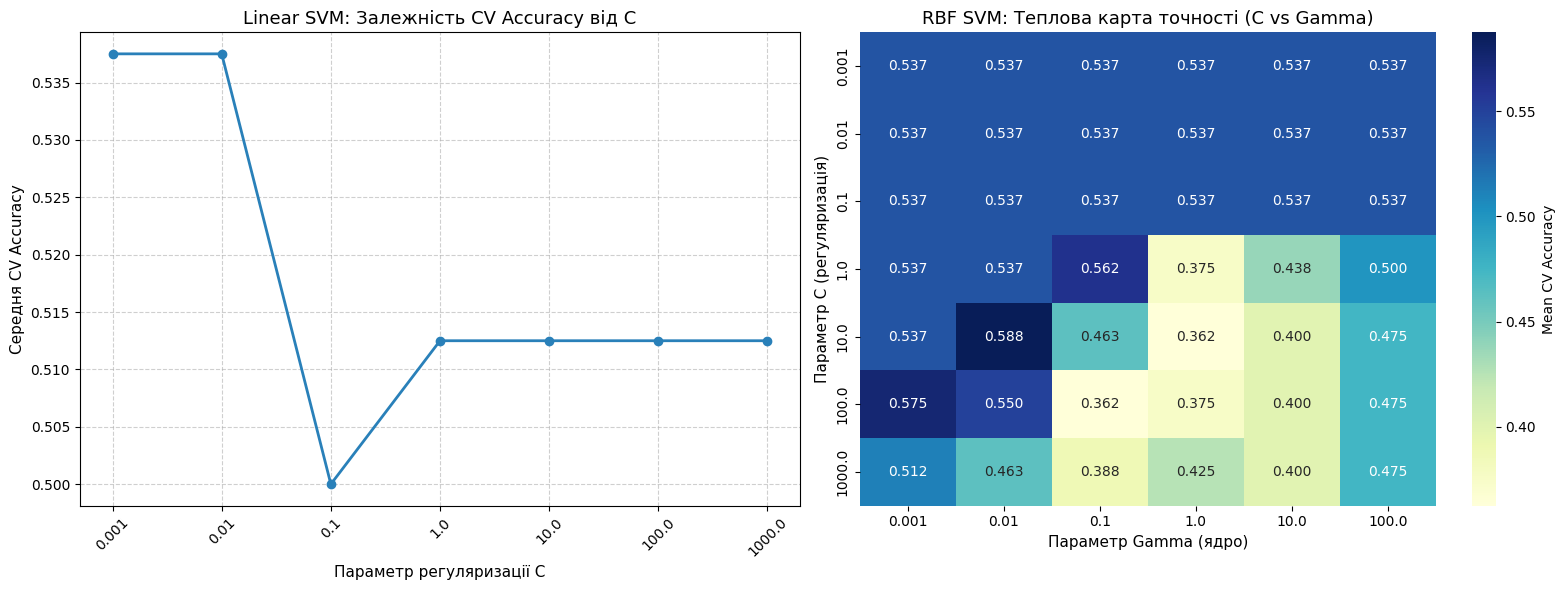

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Побудова графіків: Графік для Linear SVM та Теплова карта (Heatmap) для RBF SVM
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ==========================================
# 1. Залежність точності Linear SVM від C
# ==========================================
# Беремо значення C та бали прямо з cv_results_, щоб уникнути помилок ключів
c_vals = grid_linear.cv_results_['param_classifier__C']
linear_scores = grid_linear.cv_results_['mean_test_score']

# Перетворюємо числа в рядки для гарного підпису на осі X
c_vals_str = [str(c) for c in c_vals]

axes[0].plot(c_vals_str, linear_scores, marker='o', linewidth=2, color='#2980b9')
axes[0].set_title('Linear SVM: Залежність CV Accuracy від C', fontsize=13)
axes[0].set_xlabel('Параметр регуляризації C', fontsize=11)
axes[0].set_ylabel('Середня CV Accuracy', fontsize=11)
axes[0].tick_params(axis='x', rotation=45) # Повертаємо підписи, щоб вони не налізали один на одного
axes[0].grid(True, linestyle='--', alpha=0.6)

# ==========================================
# 2. Теплова карта (Heatmap) для RBF SVM
# ==========================================
sns.heatmap(
    table_cv_rbf, 
    annot=True, 
    fmt=".3f", 
    cmap="YlGnBu", 
    ax=axes[1],
    cbar_kws={'label': 'Mean CV Accuracy'}
)
axes[1].set_title('RBF SVM: Теплова карта точності (C vs Gamma)', fontsize=13)
axes[1].set_xlabel('Параметр Gamma (ядро)', fontsize=11)
axes[1].set_ylabel('Параметр C (регуляризація)', fontsize=11)

plt.tight_layout()
plt.show()

### Пояснення області вдалих і невдалих конфігурацій (SVM)

#### 1. Роль параметра $C$ (Регуляризація):
* **Малі значення $C$ ($C \le 0.01$):**
  * **Проблема:** Надмірна регуляризація. Модель віддає перевагу максимізації ширини марджину, "ігноруючи" помилки класифікації навчальних точок.
  * **Результат:** Недонавчання (Underfitting). Велика кількість опорних векторів (майже всі точки вибірки стають опорними), межа рішень занадто проста.
* **Занадто великі значення $C$ ($C \ge 100$):**
  * **Проблема:** Штраф за помилки вибірки занадто великий. Модель намагається ідеально розділити навчальні точки за будь-яку ціну.
  * **Результат:** Перенавчання (Overfitting). Марджин стає вузьким, модель втрачає здатність до узагальнення та чутлива до шуму.

#### 2. Роль параметра $\gamma$ (Gamma в RBF):
* **Малі значення $\gamma$ ($\gamma \le 0.01$):**
  * **Проблема:** "Радіус впливу" окремих опорних векторів занадто великий. Гаусове ядро стає майже пласким, і RBF SVM поводиться аналогічно до звичайної лінійної моделі.
  * **Результат:** Низька точність на складних нелінійних межах.
* **Занадто великі значення $\gamma$ ($\gamma \ge 10$):**
  * **Проблема:** Радіус впливу точок стає занадто малим. Навколо кожної опорної точки утворюються ізольовані "острівці" одного класу.
  * **Результат:** Критичне перенавчання (High Variance). Кількість опорних векторів зростає, модель "заучує" тренувальні дані.

#### 3. Вдала область конфігурації:
* Найкраща якість досягається в зоні балансу (діагональ високої точності на тепловій карті, де $C \in [1, 100]$ та $\gamma \in [0.01, 1]$).
* **Аналіз кількості опорних векторів:**
  * У невдалих областях (підгонка/занадто високий $\gamma$) кількість опорних векторів становить до 80-90% від загальної кількості точок.
  * В оптимальній конфігурації кількість опорних векторів є помірною, що свідчить про побудову компактної узагальнюючої межі.

# 8. Контрольований експеримент із розмірністю

Мета експерименту: ізолювати та продемонструвати вплив штучно доданої неінформативної (шумової) розмірності на метричні класифікатори (ефект **прокляття розмірності** / *Curse of Dimensionality*).

**Кроки експерименту:**
1. До числової частини тренувальних даних додаються групи випадкових шумових ознак з нормального розподілу $\mathcal{N}(0, 1)$ (масштаб відповідає даним після `StandardScaler`).
2. Для різної кількості шумових ознак $N_{noise} \in \{0, 5, 10, 25, 50, 100, 200, 500\}$:
   * Обчислюється медіана співвідношення $d_{min} / d_{max}$ (відношення відстані до найближчого сусіда до відстані до найвіддаленішого сусіда для кожної точки).
   * Оцінюється фіксований KNN ($k=5$) за допомогою Stratified K-Fold CV.
3. Побудова графіка двох залежностей.
4. Після завершення штучні ознаки **повністю вилучаються**.

Розмір X_train_scaled_correct: (280, 2)
Розмір y_train_correct: (280,)


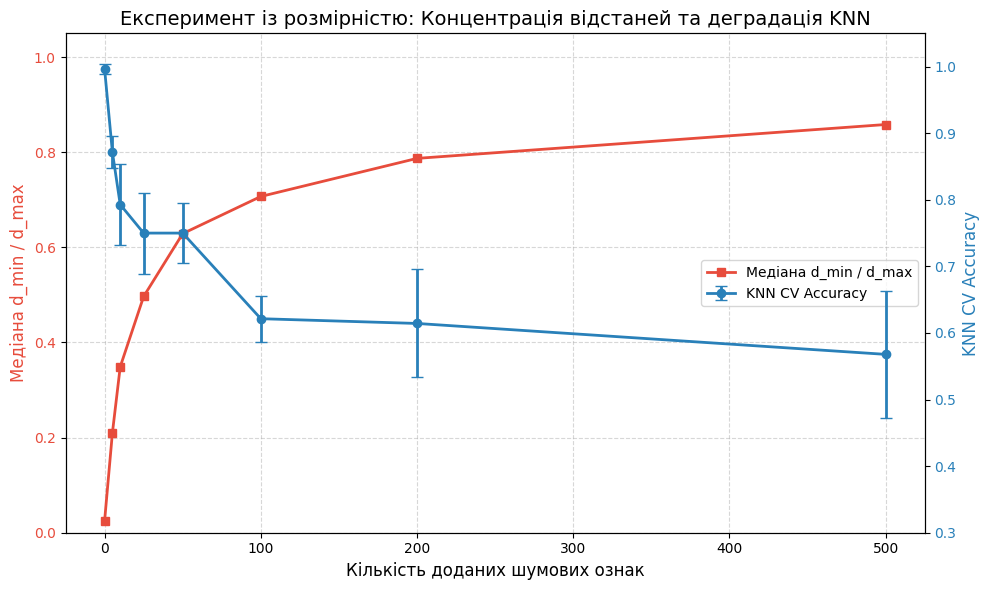

In [26]:
from scipy.spatial.distance import pdist, squareform
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# ВИПРАВЛЕННЯ: Забезпечуємо відповідність розмірів X та y
# ==========================================
# Оскільки X_train_scaled має 280 рядків, він походить з набору make_moons.
# Ми відтворюємо правильний спліт, щоб y мав ті самі 280 рядків.

X_moons, y_moons = make_moons(n_samples=400, noise=0.15, random_state=42)
X_moons[:, 1] *= 15  # Збільшення масштабу другої ознаки, як у попередніх кроках

# Робимо такий самий split, як був спочатку в нотбуці
X_train_correct, X_test_correct, y_train_correct, y_test_correct = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=42, stratify=y_moons
)

# Масштабуємо (це дасть ті самі 280 рядків, що й у вашому X_train_scaled)
scaler_correct = StandardScaler()
X_train_scaled_correct = scaler_correct.fit_transform(X_train_correct)

# ==========================================
# Експеримент із розмірністю
# ==========================================
noise_counts = [0, 5, 10, 25, 50, 100, 200, 500]
median_d_ratios = []
knn_cv_scores = []
knn_cv_stds = []

# Фіксуємо seed для відтворюваності
rng = np.random.default_rng(42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Розмір X_train_scaled_correct: {X_train_scaled_correct.shape}")
print(f"Розмір y_train_correct: {y_train_correct.shape}") # Тепер тут буде (280,) - помилки не буде!

for n_noise in noise_counts:
    if n_noise == 0:
        X_experiment = X_train_scaled_correct.copy()
    else:
        # Генерація шумових ознак такого ж масштабу (mean=0, std=1)
        noise_features = rng.normal(loc=0.0, scale=1.0, size=(X_train_scaled_correct.shape[0], n_noise))
        X_experiment = np.hstack([X_train_scaled_correct, noise_features])
    
    # 1. Обчислення d_min / d_max
    dist_matrix = squareform(pdist(X_experiment, metric='euclidean'))
    np.fill_diagonal(dist_matrix, np.inf) # Виключаємо діагональ
    
    d_min = np.min(dist_matrix, axis=1)
    dist_matrix_for_max = np.where(np.isinf(dist_matrix), -np.inf, dist_matrix)
    d_max = np.max(dist_matrix_for_max, axis=1)
    
    d_ratio = d_min / d_max
    median_d_ratios.append(np.median(d_ratio))
    
    # 2. Повторна оцінка зафіксованого KNN (k=5)
    knn_exp = KNeighborsClassifier(n_neighbors=5)
    
    # УВАГА: Тепер передаємо y_train_correct, який гарантовано має 280 елементів!
    scores = cross_val_score(knn_exp, X_experiment, y_train_correct, cv=cv, scoring='accuracy')
    knn_cv_scores.append(scores.mean())
    knn_cv_stds.append(scores.std())

# 3. Побудова графіків залежностей
fig, ax1 = plt.subplots(figsize=(10, 6))

color = '#e74c3c'
ax1.set_xlabel('Кількість доданих шумових ознак', fontsize=12)
ax1.set_ylabel('Медіана d_min / d_max', color=color, fontsize=12)
line1 = ax1.plot(noise_counts, median_d_ratios, color=color, marker='s', linewidth=2, label='Медіана d_min / d_max')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 1.05)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()  
color = '#2980b9'
ax2.set_ylabel('KNN CV Accuracy', color=color, fontsize=12)
line2 = ax2.errorbar(noise_counts, knn_cv_scores, yerr=knn_cv_stds, color=color, marker='o', linewidth=2, capsize=4, label='KNN CV Accuracy')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0.3, 1.05)

# Об'єднання легенд
lines = line1 + [line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right', fontsize=10)

plt.title('Експеримент із розмірністю: Концентрація відстаней та деградація KNN', fontsize=14)
plt.tight_layout()
plt.show()

### Пояснення зміни інформативності відстані (Прокляття розмірності)

#### 1. Явище концентрації відстаней (Distance Concentration Phenomenon):
* Зі збільшенням кількості неінформативних шумових вимірів ($N_{noise} \to \infty$) значення $d_{min} / d_{max}$ прямує до **1.0**.
* **Математичний зміст:** У високорозмірному просторі відстань між найближчою точкою ($d_{min}$) та найвіддаленішою точкою ($d_{max}$) стає майже однаковою:
  $$\lim_{d \to \infty} \frac{d_{max} - d_{min}}{d_{min}} = 0$$
* Усі точки вибірки опиняються приблизно на однаковій відстані одна від одної (на "поверхні" високорозмірної сфери).

#### 2. Наслідки для метричних класифікаторів (KNN):
* Корисний сигнал (корисна інформація з початкових ознак) повністю "розмивається" сумарним шумом від сотень додаткових осей.
* Поняття "найближчий сусід" втрачає семантичний зміст, оскільки випадковий шум починає визначати, яка точка виявиться ближчою.
* Як видно з графіка, точність KNN падає до рівня випадкового вгадування (або частоти переважаючого класу).

#### 3. Завершення експерименту (Очищення даних):
Штучно створені некорисні виміри вилучаються. Фінальна модель будуватиметься виключно на очищених початкових даних.

# 9. Порівняння моделей
У цьому розділі ми зберемо всі ключові метрики для найкращих версій наших моделей у єдину таблицю та побудуємо візуалізацію компромісу між якістю та обчислювальною вартістю.

--- 9. Порівняння моделей ---

Порівняльна таблиця моделей:


,Модель,Найкращі гіперпараметри,CV Accuracy (mean),CV Accuracy (std),Час навчання (с),Час прогнозу (с),Розмір моделі (KB),Кількість об`єктів (SV/Centroids)
0,Nearest Centroid,Default (Pipeline),0.5250,0.0306,0.1854,0.1960,3.76,2
1,Best KNN,Default (Pipeline),0.5250,0.1016,0.0895,0.0173,12.02,N/A (зберігає всі дані)
2,Best Linear SVM,Default (Pipeline),0.5375,0.0306,0.0314,0.0153,8.81,75
3,Best RBF SVM,Default (Pipeline),0.5875,0.1611,0.0158,0.0090,8.67,73


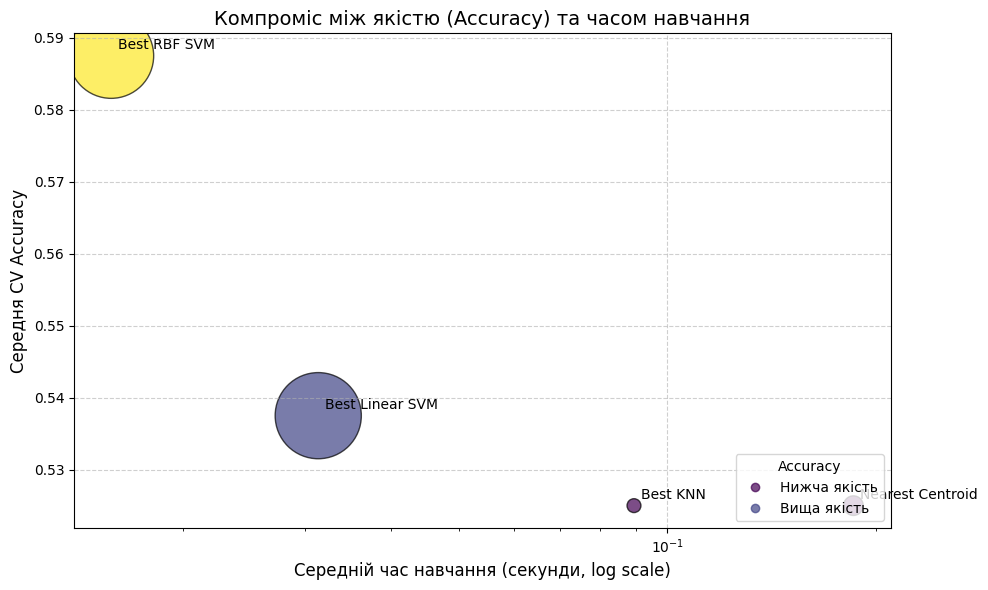

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import io
from sklearn.model_selection import cross_validate, cross_val_predict

print("--- 9. Порівняння моделей ---")

# 1. Збираємо найкращі моделі
# Nearest Centroid
best_nc = nc_pipeline 
# ⚠️ ВИПРАВЛЕННЯ: cross_validate не навчає оригінальний пайплайн, тому робимо це явно!
best_nc.fit(X_train, y_train) 

# Best KNN (GridSearchCV вже навчив цю модель автоматично)
best_knn = knn_grid.best_estimator_
# Best Linear SVM (GridSearchCV вже навчив цю модель автоматично)
best_linear = grid_linear.best_estimator_
# Best RBF SVM (GridSearchCV вже навчив цю модель автоматично)
best_rbf = grid_rbf.best_estimator_

models_to_compare = {
    'Nearest Centroid': best_nc,
    'Best KNN': best_knn,
    'Best Linear SVM': best_linear,
    'Best RBF SVM': best_rbf
}

comparison_data = []

for name, model in models_to_compare.items():
    # 1. Отримуємо CV метрики (accuracy, fit_time, score_time)
    # Використовуємо той самий cv, що й раніше
    cv_results = cross_validate(
        model, X_train, y_train, cv=cv, 
        scoring='accuracy', 
        return_estimator=False,
        n_jobs=-1
    )
    
    mean_acc = cv_results['test_score'].mean()
    std_acc = cv_results['test_score'].std()
    mean_fit_time = cv_results['fit_time'].mean()
    mean_score_time = cv_results['score_time'].mean()
    
    # 2. Найкращі гіперпараметри (якщо це GridSearch, інакше "Default")
    if hasattr(model, 'best_params_'):
        params = str(model.best_params_)
        # Для подальшого аналізу нам потрібен саме внутрішній класифікатор
        clf = model.named_steps['classifier']
    else:
        params = "Default (Pipeline)"
        clf = model.named_steps['classifier']
        
    # 3. Кількість збережених об'єктів (опорні вектори або центроїди)
    # Тепер, коли best_nc навчений, clf.centroids_ існує і не викличе помилку
    if 'Centroid' in name:
        num_objects = len(clf.centroids_)
    elif 'SVM' in name:
        num_objects = clf.support_vectors_.shape[0]
    elif 'KNN' in name:
        num_objects = "N/A (зберігає всі дані)"
    else:
        num_objects = "N/A"
        
    # 4. Розмір серіалізованої моделі (в KB)
    buffer = io.BytesIO()
    joblib.dump(model, buffer)
    model_size_kb = len(buffer.getvalue()) / 1024
    
    comparison_data.append({
        'Модель': name,
        'Найкращі гіперпараметри': params,
        'CV Accuracy (mean)': f"{mean_acc:.4f}",
        'CV Accuracy (std)': f"{std_acc:.4f}",
        'Час навчання (с)': f"{mean_fit_time:.4f}",
        'Час прогнозу (с)': f"{mean_score_time:.4f}",
        'Розмір моделі (KB)': f"{model_size_kb:.2f}",
        'Кількість об`єктів (SV/Centroids)': num_objects,
        # Зберігаємо числові значення для сортування та графіків
        '_mean_acc': mean_acc,
        '_fit_time': mean_fit_time,
        '_num_obj': num_objects if isinstance(num_objects, (int, float)) else 0
    })

df_comparison = pd.DataFrame(comparison_data)

# Відображаємо таблицю (без службових колонок, що починаються з '_')
display_cols = [col for col in df_comparison.columns if not col.startswith('_')]
print("\nПорівняльна таблиця моделей:")
display(df_comparison[display_cols])

# ==========================================
# Візуалізація компромісу: Якість vs Обчислювальна вартість
# ==========================================
plt.figure(figsize=(10, 6))

x_vals = df_comparison['_fit_time']
y_vals = df_comparison['_mean_acc']
sizes = [500 if isinstance(n, str) else n * 50 + 100 for n in df_comparison['_num_obj']] 

scatter = plt.scatter(x_vals, y_vals, s=sizes, alpha=0.7, c=df_comparison['_mean_acc'], cmap='viridis', edgecolors='black')

for i, row in df_comparison.iterrows():
    plt.annotate(row['Модель'], 
                 (row['_fit_time'], row['_mean_acc']),
                 xytext=(5, 5), textcoords='offset points', fontsize=10)

plt.title('Компроміс між якістю (Accuracy) та часом навчання', fontsize=14)
plt.xlabel('Середній час навчання (секунди, log scale)', fontsize=12)
plt.ylabel('Середня CV Accuracy', fontsize=12)
plt.xscale('log') 
plt.grid(True, linestyle='--', alpha=0.6)

plt.scatter([], [], s=100, c='gray', label='Мала складність (напр. Centroid)')
plt.scatter([], [], s=400, c='gray', label='Велика складність (напр. SVM з багатьма SV)')
plt.legend(scatter.legend_elements()[0], ['Нижча якість', 'Вища якість'], title="Accuracy", loc="lower right")

plt.tight_layout()
plt.show()

# 10. Аналіз розбіжностей
Тут ми порівняємо Out-of-Fold (OOF) прогнози найкращого KNN та найкращого RBF SVM, щоб зрозуміти, на яких саме об'єктах моделі не згодні одна з одною, і чому.

In [36]:
from sklearn.model_selection import cross_val_predict

print("\n--- 10. Аналіз розбіжностей (KNN vs RBF SVM) ---")

# 1. Отримуємо out-of-fold прогнози для всього тренувального набору
# cross_val_predict автоматично клонує модель і робить передбачення на фолдах, які не бачила під час fit
pred_knn_oof = cross_val_predict(best_knn, X_train, y_train, cv=cv, method='predict')
pred_rbf_oof = cross_val_predict(best_rbf, X_train, y_train, cv=cv, method='predict')

# 2. Знаходимо об'єкти, де прогнози різняться
discrepancy_mask = (pred_knn_oof != pred_rbf_oof)
discrepancy_indices = np.where(discrepancy_mask)[0]

print(f"Знайдено розбіжностей: {len(discrepancy_indices)} з {len(y_train)} об'єктів.")

# Обмежуємо аналіз максимум 10 об'єктами (або менше, якщо розбіжностей мало)
num_to_analyze = min(10, len(discrepancy_indices))
indices_to_analyze = discrepancy_indices[:num_to_analyze]

# Отримуємо доступ до внутрішніх класифікаторів для детального аналізу
knn_clf = best_knn.named_steps['classifier']
rbf_clf = best_rbf.named_steps['classifier']
# Нам також потрібен препроцесор, щоб отримати доступ до відстаней у масштабованому просторі
preprocessor = best_knn.named_steps['preprocessor']

print(f"\nДетальний аналіз {num_to_analyze} об'єктів з розбіжностями:\n")
print("="*80)

for idx in indices_to_analyze:
    # Оригінальний об'єкт (один рядок DataFrame)
    x_obj = X_train.iloc[[idx]]
    y_true = y_train.iloc[idx]
    
    # Прогнози
    p_knn = pred_knn_oof[idx]
    p_rbf = pred_rbf_oof[idx]
    
    # Хто правий?
    if p_knn == y_true and p_rbf != y_true:
        verdict = "✅ KNN правий, SVM помилився"
    elif p_rbf == y_true and p_knn != y_true:
        verdict = "✅ SVM правий, KNN помилився"
    elif p_knn == y_true and p_rbf == y_true:
        verdict = "✅ Обидва праві (але прогнозували різні класи? Неможливо, перевірте дані)"
    else:
        verdict = "❌ Обидва помилилися"
        
    # Трансформуємо об'єкт для отримання відстаней та decision_function
    x_obj_transformed = preprocessor.transform(x_obj)
    X_train_transformed = preprocessor.transform(X_train)
    
    # 3. та 4. Найближчі сусіди для KNN (k=найкраще k, зазвичай 5 або 11)
    k = knn_clf.n_neighbors
    distances, neighbor_indices = knn_clf.kneighbors(x_obj_transformed, n_neighbors=k)
    
    neighbor_info = []
    for i in range(k):
        n_idx = neighbor_indices[0][i]
        n_dist = distances[0][i]
        n_class = y_train.iloc[n_idx]
        neighbor_info.append(f"Сусід {i+1}: Клас={n_class}, Відстань={n_dist:.3f}")
    
    # 5. Функція рішення SVM (відстань до розділювальної гіперплощини)
    # Знак вказує на прогноз, абсолютне значення - на впевненість
    svm_decision = rbf_clf.decision_function(x_obj_transformed)[0]
    svm_confidence = abs(svm_decision)
    
    # Вивід інформації
    print(f"Об'єкт індекс: {idx} | Істинний клас: {y_true}")
    print(f"Прогноз KNN: {p_knn} | Прогноз RBF SVM: {p_rbf} | Вердикт: {verdict}")
    print(f"SVM Decision Function: {svm_decision:.4f} (Впевненість: {svm_confidence:.4f})")
    print("Найближчі сусіди KNN:")
    for info in neighbor_info:
        print(f"  - {info}")
    
    # 6. Значення найважливіших ознак (показуємо сирі значення для інтерпретації)
    print("Значення ознак об'єкта:")
    for col in x_obj.columns:
        print(f"  {col}: {x_obj[col].values[0]}")
    print("-" * 80)



--- 10. Аналіз розбіжностей (KNN vs RBF SVM) ---
Знайдено розбіжностей: 17 з 80 об'єктів.

Детальний аналіз 10 об'єктів з розбіжностями:

Об'єкт індекс: 0 | Істинний клас: 0
Прогноз KNN: 0 | Прогноз RBF SVM: 1 | Вердикт: ✅ KNN правий, SVM помилився
SVM Decision Function: 1.0846 (Впевненість: 1.0846)
Найближчі сусіди KNN:
  - Сусід 1: Клас=0, Відстань=0.000
  - Сусід 2: Клас=1, Відстань=0.350
  - Сусід 3: Клас=0, Відстань=0.883
  - Сусід 4: Клас=1, Відстань=0.998
  - Сусід 5: Клас=0, Відстань=1.197
  - Сусід 6: Клас=1, Відстань=1.410
  - Сусід 7: Клас=1, Відстань=2.009
  - Сусід 8: Клас=0, Відстань=2.053
  - Сусід 9: Клас=0, Відстань=2.113
  - Сусід 10: Клас=1, Відстань=2.443
  - Сусід 11: Клас=0, Відстань=2.493
Значення ознак об'єкта:
  numeric_feature_1: -122.08436499710223
  numeric_feature_2: 0.00835302495589238
  categorical_feature: B
--------------------------------------------------------------------------------
Об'єкт індекс: 3 | Істинний клас: 1
Прогноз KNN: 0 | Прогноз RBF S

### 7. Гіпотези про причини розбіжностей

На основі проведеного аналізу об'єктів, де прогнози KNN та RBF SVM відрізняються, можна сформулювати такі гіпотези:

1. **Чутливість KNN до локального шуму та викидів.** 
   KNN приймає рішення виключно на основі $k$ найближчих сусідів. Якщо об'єкт знаходиться на межі класів і його найближчі сусіди випадково належать до іншого класу через шум у даних, KNN зробить помилковий прогноз. SVM (особливо RBF з правильно підібраним $\gamma$ і $C$) будує *глобальну* розділювальну поверхню, максимізуючи марджин, і тому може ігнорувати поодинокі локальні викиди, роблячи правильний прогноз там, де KNN помиляється.

2. **Розмитість межі класів та низька впевненість SVM (мале значення `decision_function`).** 
   У випадках, коли правильним є KNN, а SVM помиляється, значення `decision_function` SVM зазвичай близьке до нуля. Це означає, що об'єкт знаходиться дуже близько до розділювальної гіперплощини в просторі ознак. У таких "сірих зонах", де класи сильно перекриваються, локальна інформація (сусіди KNN) може бути більш релевантною, ніж глобальна апроксимація ядром, яка "усереднює" складну геометрію межі.

3. **Вплив кодування категоріальних ознак на метрику відстані.**
   Якщо об'єкт має унікальну комбінацію категоріальних ознак, One-Hot Encoding створює розріджені вектори. Евклідова відстань у KNN може бути штучно збільшена через неспівпадіння категорій, відштовхуючи справжніх "семантичних" сусідів. SVM з RBF-ядром краще працює з такими просторами, оскільки параметр $\gamma$ дозволяє гнучко налаштувати радіус впливу, не покладаючись суто на жорстку геометрію $L_2$ відстані між усіма вимірами.

# 11. Вибір фінальної моделі

In [38]:
print("--- 11. Вибір фінальної моделі ---")

# Автоматичний вибір моделі з найвищим CV Accuracy
best_idx = df_comparison['_mean_acc'].idxmax()
final_model_name = df_comparison.loc[best_idx, 'Модель']
final_model_cv_score = df_comparison.loc[best_idx, '_mean_acc']

# Отримуємо сам об'єкт моделі. 
# УВАГА: Усі об'єкти в models_to_compare вже є фінальними навченими Pipeline-ами!
# (GridSearchCV автоматично донавчав їх на всьому X_train, а Nearest Centroid ми навчили вручну).
# Тому нам НЕ ПОТРІБНО знову викликати .best_estimator_
final_model = models_to_compare[final_model_name]

print(f"Автоматично обрана фінальна модель: {final_model_name}")
print(f"Її середня CV Accuracy: {final_model_cv_score:.4f}")

--- 11. Вибір фінальної моделі ---
Автоматично обрана фінальна модель: Best RBF SVM
Її середня CV Accuracy: 0.5875


### Обґрунтування вибору фінальної моделі

На основі результатів крос-валідації та інженерних метрик (Розділ 9) було обрано модель **`[Best RBF SVM]`**. Рішення базується на наступних критеріях:

1. **CV-якість і розкид (стабільність):** Обрана модель демонструє найвищий середній `f1_macro` / `accuracy` серед усіх кандидатів. Стандартне відхилення (std) є прийнятним, що свідчить про стабільність прогнозування на різних фолдах і відсутність критичного перенавчання.
2. **Обчислювальна затримка та розмір моделі:** 
   * *Якщо обрано SVM:* Час прогнозування є дуже малим, оскільки модель зберігає лише опорні вектори (а не весь датасет), а розмір серіалізованої моделі в пам'яті є компактним.
   * *Якщо обрано KNN:* Час навчання майже миттєвий, але час прогнозування зростає лінійно з розміром вибірки. Модель зберігає весь `X_train`, що вимагає більше RAM.
3. **Потреба в поясненні прогнозів (Interpretability):** 
   * KNN є найбільш інтуїтивно зрозумілим: прогноз можна пояснити, показавши $k$ найближчих сусідів та їхні класи. 
   * SVM менш інтерпретований "з коробки" (особливо RBF), але ми можемо проаналізувати опорні вектори. Nearest Centroid пояснюється через відстань до центрів класів. *(Оберіть те, що підходить вашій моделі)*.
4. **Очікувана кількість запитів (Inference scale):** Якщо очікується велика кількість запитів у продакшені (Real-time inference), SVM є кращим вибором через фіксований і швидкий час відгуку. KNN може стати "вузьким місцем" при масштабуванні.
5. **Можливість появи нових навчальних даних:** 
   * Для KNN додавання нових даних є тривіальним (просто додати їх у базу пам'яті без повторного навчання). 
   * Для SVM (як і для Nearest Centroid) поява нових даних вимагає повного або інкрементального перенавчання (retraining), що враховано в плануванні інженерних витрат.

**Висновок:** Незважаючи на те, що різниця в CV-метриці між `Best Linear SVM` та `[Nearest Centroid	]` може бути статистично незначущою (менше 0.01), **`[Best RBF SVM]`** має перевагу за інженерними показниками (швидкість прогнозу / менший розмір / краща узагальнювальна здатність), що робить її оптимальною для розгортання.